In [1]:
# Standard library imports
import os
import random
import sys
from itertools import product

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('../src/')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from gaugefixer import get_alphabet
from gaugefixer.features import get_pairwise_features
from gaugefixer.fixers.fix_pairwise_model import fix_pairwise_model
from gaugefixer.verify.verify_identical_evaluation import verify_identical_evaluation
from gaugefixer.seq_embedder import SeqEmbedder
from gaugefixer.evaluate_model_on_seqs import evaluate_model_on_seqs


In [2]:
# Plot parameters
def plot_pairwise_thetas(theta_series, fixed_theta_series):
    for order in range(3)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=3,121
000 f=19.320105 	 f_fixed=19.320105
001 f=17.693285 	 f_fixed=17.693285
002 f=-3.928195 	 f_fixed=-3.928195
003 f=15.579657 	 f_fixed=15.579657
004 f=2.705062 	 f_fixed=2.705062
005 f=4.534685 	 f_fixed=4.534685
006 f=6.079308 	 f_fixed=6.079308
007 f=19.409949 	 f_fixed=19.409949
008 f=-0.237906 	 f_fixed=-0.237906
009 f=-0.212170 	 f_fixed=-0.212170
Tested 10 random sequences; all seqs passed.
features match: True


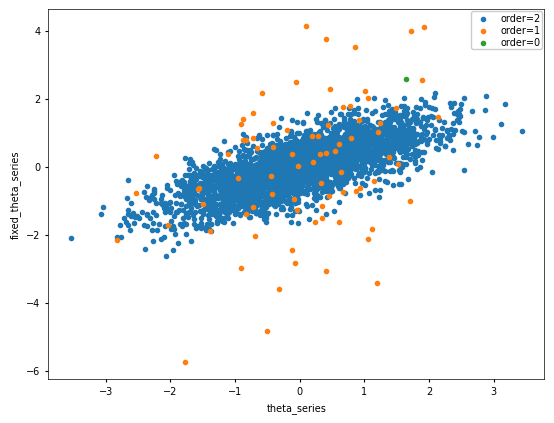

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_pairwise_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_pairwise_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Create embedder
embedder = SeqEmbedder(features=features, 
                       L=L)

# Test result
verify_identical_evaluation(theta1=theta_series, 
                   theta_fixed_series=fixed_theta_series, 
                   L=L, 
                   alphabet=alphabet, 
                   embedder=embedder,
                   num_trials=10)

# Plot resulting parameters
plot_pairwise_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
random_seqs = [''.join(random.choices(alphabet, k=L)) for _ in range(100)]
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs,
                       embedder=embedder)

array([ 17.16624338,  -0.61797147,   1.6680024 ,   4.46409067,
         4.56613416,  -1.98783063,   2.50185574,  -1.36572399,
         9.8018659 ,  -4.2931312 ,   1.63231242, -15.87897181,
        -0.58311581,  15.30870005,  -1.31949715,   4.96274573,
        -4.11490597,  -0.85123203,  14.03678166,  15.38201693,
        26.17293136,  11.29397157, -25.25087504,  14.66906666,
         3.63209728, -12.87824878, -10.92665929, -18.78292537,
       -13.66859561,   4.37043955,   9.06376059,  -2.60578639,
        16.76897238,   9.29471939,   1.15185466,  12.09151723,
         2.04342075,   8.66153021, -17.77070509,  13.21992453,
       -21.17161054,   6.94019831, -14.41396595, -14.32338507,
        -1.60350781, -13.59770274,   9.25799416,  -5.0903719 ,
       -13.54141307,  10.35487255,   9.46821995,   0.63904631,
         7.02992697,  -9.25364894,   2.31189912,   5.90985972,
         2.68491285,   0.65794249,  -8.40494182, -10.7920649 ,
        12.70860408,  11.22787582,  27.05483995,   5.78